# Regression in Python

***
This is a very quick run-through of some basic statistical concepts, adapted from [Lab 4 in Harvard's CS109](https://github.com/cs109/2015lab4) course. Please feel free to try the original lab if you're feeling ambitious :-) The CS109 git repository also has the solutions if you're stuck.

* Linear Regression Models
* Prediction using linear regression

Linear regression is used to model and predict continuous outcomes with normal random errors. There are nearly an infinite number of different types of regression models and each regression model is typically defined by the distribution of the prediction errors (called "residuals") of the type of data. Logistic regression is used to model binary outcomes whereas Poisson regression is used to predict counts. In this exercise, we'll see some examples of linear regression as well as Train-test splits.

The packages we'll cover are: `statsmodels`, `seaborn`, and `scikit-learn`. While we don't explicitly teach `statsmodels` and `seaborn` in the Springboard workshop, those are great libraries to know.
***

<img width=600 height=300 src="https://imgs.xkcd.com/comics/sustainable.png"/>
***

In [1]:
# special IPython command to prepare the notebook for matplotlib and other libraries
%matplotlib inline 

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn

import seaborn as sns

# special matplotlib argument for improved plots
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")


***

# Part 1: Introduction to Linear Regression

### Purpose of linear regression

***

<div class="span5 alert alert-info">



<p> Given a dataset containing predictor variables $X$ and outcome/response variable $Y$, linear regression can be used to: </p>

<ul>

  <li> Build a <b>predictive model</b> to predict future values of $\hat{Y}$, using new data $X^*$ where $Y$ is unknown.</li>

  <li> Model the <b>strength of the relationship</b> between each independent variable $X_i$ and $Y$</li>

    <ul>

      <li> Many times, only a subset of independent variables $X_i$ will have a linear relationship with $Y$</li>

      <li> Need to figure out which $X_i$ contributes most information to predict $Y$ </li>

    </ul>

   <li>It is in many cases, the first pass prediction algorithm for continuous outcomes. </li>

</ul>

</div>



### A Brief Mathematical Recap

***



[Linear Regression](http://en.wikipedia.org/wiki/Linear_regression) is a method to model the relationship between a set of independent variables $X$ (also knowns as explanatory variables, features, predictors) and a dependent variable $Y$.  This method assumes the relationship between each predictor $X$ is **linearly** related to the dependent variable $Y$. The most basic linear regression model contains one independent variable $X$, we'll call this the simple model. 



$$Y = \beta_0 + \beta_1 X + \epsilon$$



where $\epsilon$ is considered as an unobservable random variable that adds noise to the linear relationship. In linear regression, $\epsilon$ is assumed to be normally distributed with a mean of 0. In other words, what this means is that on average, if we know $Y$, a roughly equal number of predictions $\hat{Y}$ will be above $Y$ and others will be below $Y$. That is, on average, the error is zero. The residuals, $\epsilon$ are also assumed to be "i.i.d.": independently and identically distributed. Independence means that the residuals are not correlated -- the residual from one prediction has no effect on the residual from another prediction. Correlated errors are common in time series analysis and spatial analyses.



* $\beta_0$ is the intercept of the linear model and represents the average of $Y$ when all independent variables $X$ are set to 0.



* $\beta_1$ is the slope of the line associated with the regression model and represents the average effect of a one-unit increase in $X$ on $Y$.



* Back to the simple model. The model in linear regression is the *conditional mean* of $Y$ given the values in $X$ is expressed a linear function.  



$$ y = f(x) = E(Y | X = x) $$



![conditional mean](images/conditionalmean.png)

*Image from http://www.learner.org/courses/againstallodds/about/glossary.html. Note this image uses $\alpha$ and $\beta$ instead of $\beta_0$ and $\beta_1$.*



* The goal is to estimate the coefficients (e.g. $\beta_0$ and $\beta_1$). We represent the estimates of the coefficients with a "hat" on top of the letter.  



$$\hat{\beta}_0, \hat{\beta}_1$$



* Once we estimate the coefficients $\hat{\beta}_0$ and $\hat{\beta}_1$, we can use these to predict new values of $Y$ given new data $X$.



$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1$$



* Multiple linear regression is when you have more than one independent variable and the estimation involves matrices

    * $X_1$, $X_2$, $X_3$, $\ldots$





* How do you estimate the coefficients? 

    * There are many ways to fit a linear regression model

    * The method called **least squares** is the most common methods

    * We will discuss least squares



$$Y = \beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p + \epsilon$$



### Estimating $\hat{\beta}$: Least squares

***

[Least squares](http://en.wikipedia.org/wiki/Least_squares) is a method that can estimate the coefficients of a linear model by minimizing the squared residuals: 



$$\mathscr{L} = \sum_{i=1}^N \epsilon_i^2 = \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2  = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2$$



where $N$ is the number of observations and $\epsilon$ represents a residual or error, ACTUAL - PREDICTED.  



#### Estimating the intercept $\hat{\beta}_0$ for the simple linear model



We want to minimize the squared residuals and solve for $\hat{\beta}_0$ so we take the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta}_0$ 

$$

\begin{align}

\frac{\partial \mathscr{L}}{\partial \hat{\beta_0}} &= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \epsilon^2 \\

&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\

&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\

&= -2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \hspace{25mm} \text{(by chain rule)} \\

&= -2 \sum_{i=1}^N (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i) \\

&= -2 \left[ \left( \sum_{i=1}^N y_i \right) - N \hat{\beta_0} - \hat{\beta}_1 \left( \sum_{i=1}^N x_i

\right) \right] \\

& 2 \left[ N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i \right] = 0 \hspace{20mm} \text{(Set equal to 0 and solve for $\hat{\beta}_0$)} \\

& N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i = 0 \\

& N \hat{\beta}_0 = \sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i \\

& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i}{N} \\

& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i}{N} - \hat{\beta}_1 \frac{\sum_{i=1}^N x_i}{N} \\

& \boxed{\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}}

\end{align}

$$

Using this new information, we can compute the estimate for $\hat{\beta}_1$ by taking the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta}_1$.

$$

\begin{align}

\frac{\partial \mathscr{L}}{\partial \hat{\beta_1}} &= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \epsilon^2 \\

&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\

&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\

&= 2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \left( -x_i \right) \hspace{25mm}\text{(by chain rule)} \\

&= -2 \sum_{i=1}^N x_i \left( y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i \right) \\

&= -2 \sum_{i=1}^N x_i (y_i - \hat{\beta}_0 x_i - \hat{\beta}_1 x_i^2) \\

&= -2 \sum_{i=1}^N x_i (y_i - \left( \bar{y} - \hat{\beta}_1 \bar{x} \right) x_i - \hat{\beta}_1 x_i^2) \\

&= -2 \sum_{i=1}^N (x_i y_i - \bar{y}x_i + \hat{\beta}_1\bar{x}x_i - \hat{\beta}_1 x_i^2) \\

&= -2 \left[ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i + \hat{\beta}_1\bar{x}\sum_{i=1}^N x_i - \hat{\beta}_1 \sum_{i=1}^N x_i^2 \right] \\

&= -2 \left[ \hat{\beta}_1 \left\{ \bar{x} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i^2 \right\} + \left\{ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i \right\}\right] \\

& 2 \left[ \hat{\beta}_1 \left\{ \sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i \right\} + \left\{ \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right\} \right] = 0 \\

& \hat{\beta}_1 = \frac{-\left( \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right)}{\sum_{i=1}^N x_i^2 - \bar{x}\sum_{i=1}^N x_i} \\

&= \frac{\sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i}{\sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i} \\

& \boxed{\hat{\beta}_1 = \frac{\sum_{i=1}^N x_i y_i - \bar{x}\bar{y}n}{\sum_{i=1}^N x_i^2 - n \bar{x}^2}}

\end{align}

$$

The solution can be written in compact matrix notation as



$$\hat{\beta} =  (X^T X)^{-1}X^T Y$$



We wanted to show you this in case you remember linear algebra, in order for this solution to exist we need $X^T X$ to be invertible. Of course this requires a few extra assumptions, $X$ must be full rank so that $X^T X$ is invertible, etc. Basically, $X^T X$ is full rank if all rows and columns are linearly independent. This has a loose relationship to variables and observations being independent respective. **This is important for us because this means that having redundant features in our regression models will lead to poorly fitting (and unstable) models.** We'll see an implementation of this in the extra linear regression example.

***
# Part 2: Exploratory Data Analysis for Linear Relationships

The [Boston Housing data set](https://archive.ics.uci.edu/ml/datasets/Housing) contains information about the housing values in suburbs of Boston.  This dataset was originally taken from the StatLib library which is maintained at Carnegie Mellon University and is now available on the UCI Machine Learning Repository. 


## Load the Boston Housing data set from `sklearn`
***

This data set is available in the [sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html#sklearn.datasets.load_boston) python module which is how we will access it today.  

In [2]:
import pandas as pd

bos = pd.read_csv('boston.csv')
print(bos.shape)
bos.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


Now we have a pandas DataFrame called `bos` containing all the data we want to use to predict Boston Housing prices.  Let's rename the target variable of `MEDV` to `PRICE` which will contain the prices. 

In [3]:
bos = bos.rename(columns={"MEDV":"PRICE"})
bos.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## EDA and Summary Statistics
***

Let's explore this data set.  First we use `describe()` to get basic summary statistics for each of the columns. 

In [4]:
bos.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Scatterplots
***

Let's look at some scatter plots for three variables: 'CRIM' (per capita crime rate), 'RM' (number of rooms) and 'PTRATIO' (pupil-to-teacher ratio in schools).  

Text(0.5, 1.0, 'Relationship between CRIM and Price')

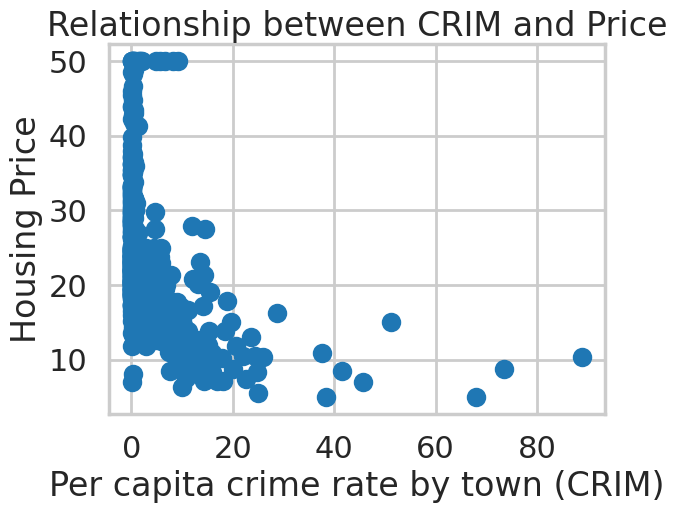

In [5]:
plt.scatter(bos.CRIM, bos.PRICE)
plt.xlabel("Per capita crime rate by town (CRIM)")
plt.ylabel("Housing Price")
plt.title("Relationship between CRIM and Price")

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> What kind of relationship do you see? e.g. positive, negative?  linear? non-linear? Is there anything else strange or interesting about the data? What about outliers?</p>


<p><b>Exercise:</b> Create scatter plots between *RM* and *PRICE*, and *PTRATIO* and *PRICE*. Label your axes appropriately using human readable labels. Tell a story about what you see.</p>

<p><b>Exercise:</b> What are some other numeric variables of interest? Why do you think they are interesting? Plot scatterplots with these variables and *PRICE* (house price) and tell a story about what you see.</p>

</div>

*your turn: describe the relationship between **CRIM** and **PRICE***

The relationship between CRIM and Price is negative, meaning that as the crime rate increases housing prices tends to decrease. The relationship appears to be fairly nonlinear however, with most data clustering at `CRIM <= 10`, and varying greatly in price. Various towns having a significantly higher crime rate cause the data to be pretty strongly right-skewed, and a significantly lower average in house pricing can be observed in these outliers.

Text(0.5, 1.0, 'Relationship between RM and Price')

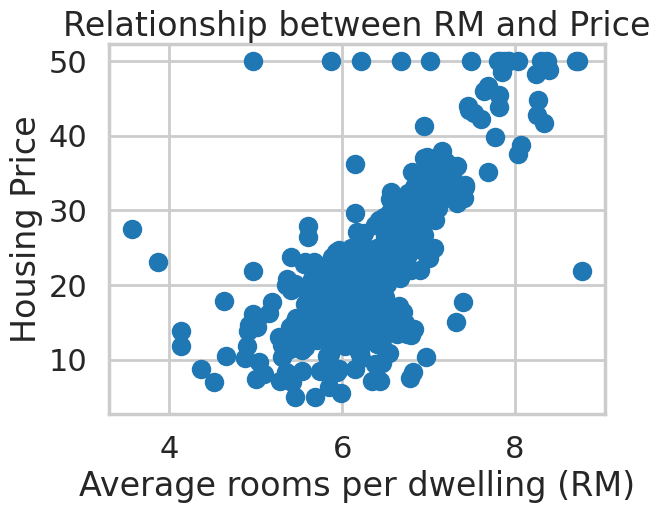

In [6]:
# your turn: scatter plot between *RM* and *PRICE*

plt.scatter(bos.RM, bos.PRICE)
plt.xlabel("Average rooms per dwelling (RM)")
plt.ylabel("Housing Price")
plt.title("Relationship between RM and Price")

Text(0.5, 1.0, 'Relationship between PTRATIO and Price')

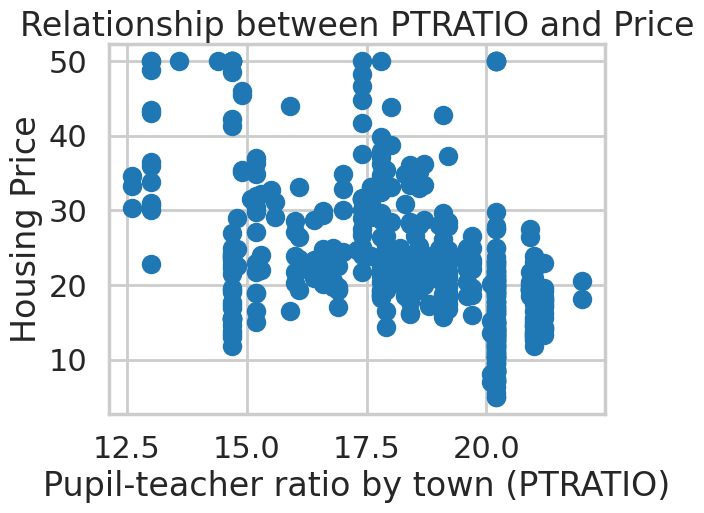

In [7]:
# your turn: scatter plot between *PTRATIO* and *PRICE*

plt.scatter(bos.PTRATIO, bos.PRICE)
plt.xlabel("Pupil-teacher ratio by town (PTRATIO)")
plt.ylabel("Housing Price")
plt.title("Relationship between PTRATIO and Price")

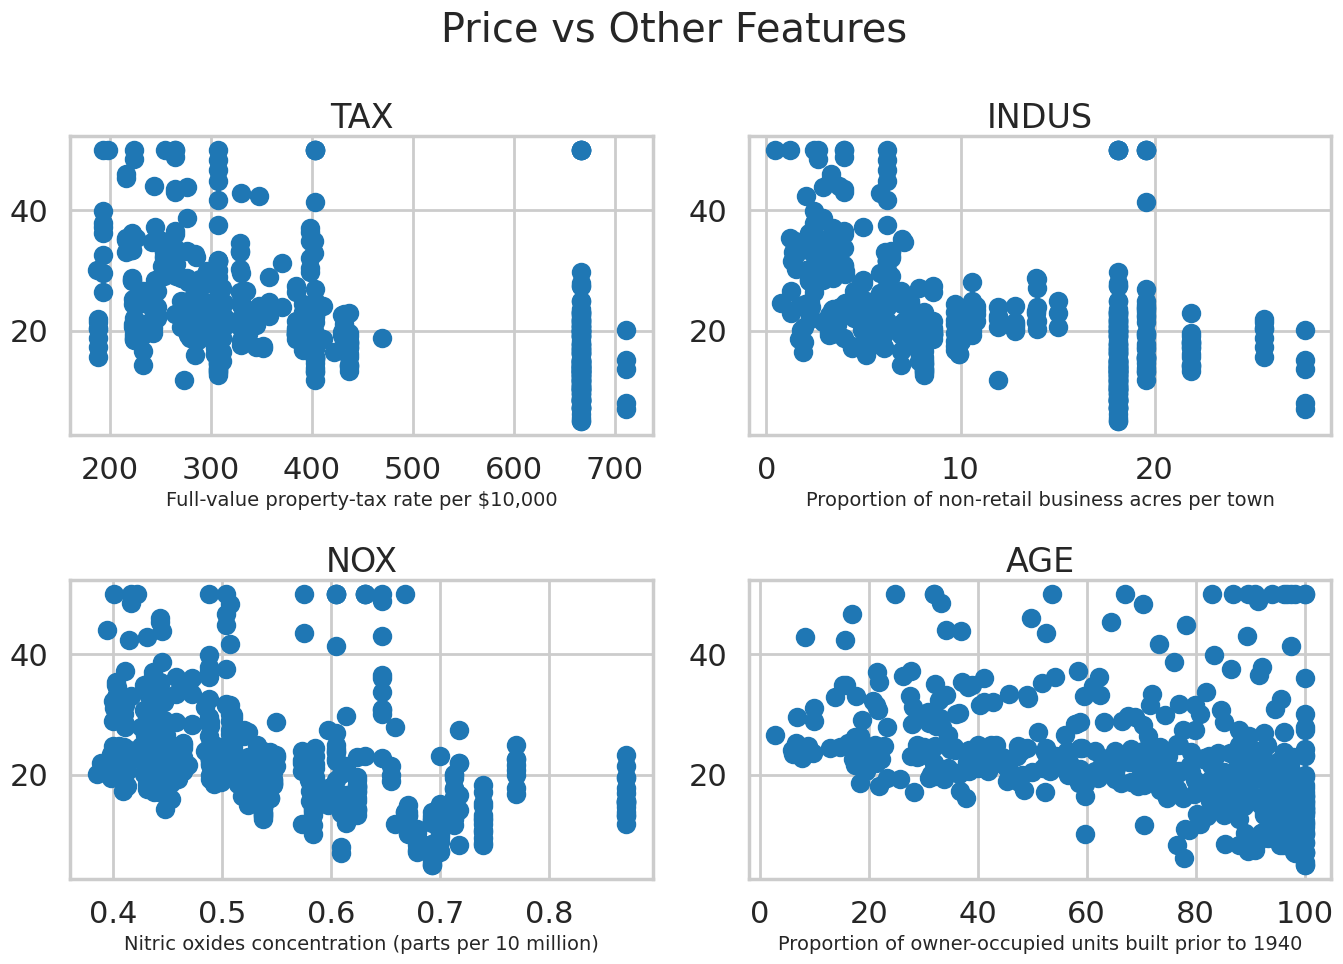

In [8]:
# your turn: create some other scatter plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(bos['TAX'], bos['PRICE'])
axes[0, 0].set_title("TAX")
axes[0, 0].set_xlabel("Full-value property-tax rate per $10,000", fontsize=14)

axes[0, 1].scatter(bos['INDUS'], bos['PRICE'])
axes[0, 1].set_title("INDUS")
axes[0, 1].set_xlabel("Proportion of non-retail business acres per town", fontsize=14)

axes[1, 0].scatter(bos['NOX'], bos['PRICE'])
axes[1, 0].set_title("NOX")
axes[1, 0].set_xlabel("Nitric oxides concentration (parts per 10 million)", fontsize=14)

axes[1, 1].scatter(bos['AGE'], bos['PRICE'])
axes[1, 1].set_title("AGE")
axes[1, 1].set_xlabel("Proportion of owner-occupied units built prior to 1940", fontsize=14)

fig.suptitle("Price vs Other Features")
fig.tight_layout()
plt.show()

### Scatterplots using Seaborn
***

[Seaborn](https://stanford.edu/~mwaskom/software/seaborn/) is a cool Python plotting library built on top of matplotlib. It provides convenient syntax and shortcuts for many common types of plots, along with better-looking defaults.

We can also use [seaborn regplot](https://stanford.edu/~mwaskom/software/seaborn/tutorial/regression.html#functions-to-draw-linear-regression-models) for the scatterplot above. This provides automatic linear regression fits (useful for data exploration later on). Here's one example below.

<Axes: xlabel='RM', ylabel='PRICE'>

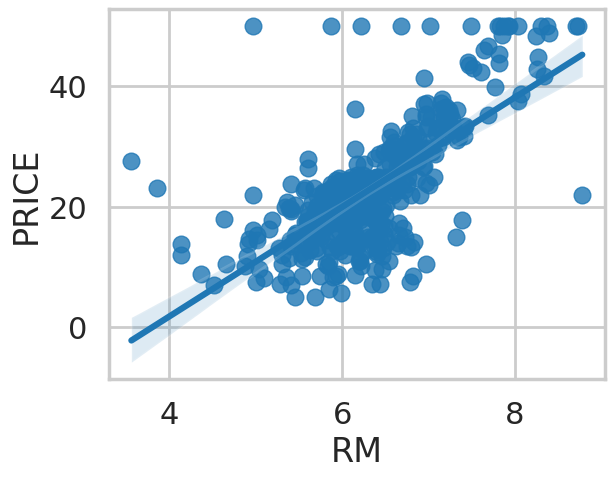

In [9]:
sns.regplot(y="PRICE", x="RM", data=bos, fit_reg = True)

### Histograms
***


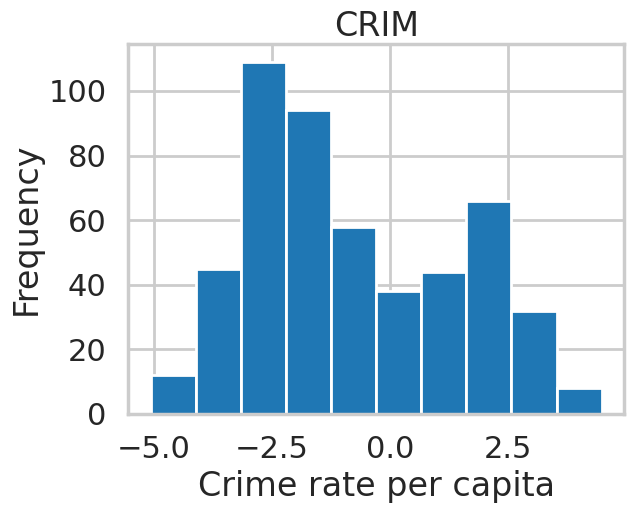

In [10]:
plt.hist(np.log(bos.CRIM))
plt.title("CRIM")
plt.xlabel("Crime rate per capita")
plt.ylabel("Frequency")
plt.show()

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> In the above histogram, we took the logarithm of the crime rate per capita. Repeat this histogram without taking the log. What was the purpose of taking the log? What do we gain by making this transformation? What do you now notice about this variable that is not obvious without making the transformation?

<p><b>Exercise:</b> Plot the histogram for *RM* and *PTRATIO* against each other, along with the two variables you picked in the previous section. We are looking for correlations in predictors here.</p>
</div>

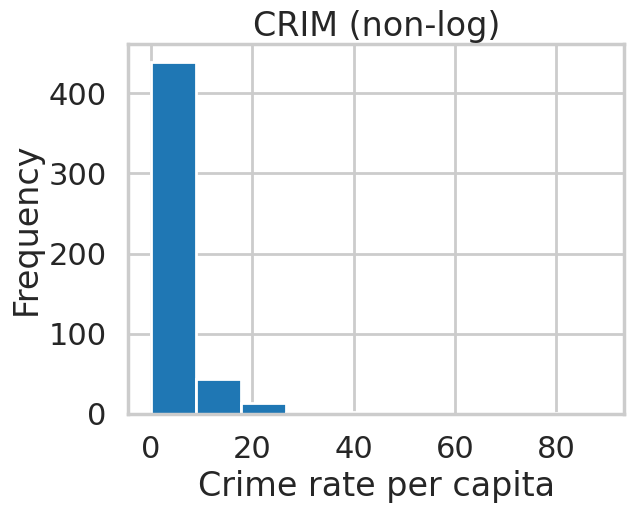

In [11]:
#your turn
plt.hist(bos.CRIM)
plt.title("CRIM (non-log)")
plt.xlabel("Crime rate per capita")
plt.ylabel("Frequency")
plt.show()

Crime rate per capita appears to be a ratio that typically sits mostly in the range of $0 \le 1$, meaning a non-log view of this distribution results in a heavily right-skewed histogram. Taking the log helps compress the larger values and spread out the distribution a bit more evenly to provide an easier visualization to interpret.

Had we not taken the log of `CRIM`, I wouldn't have known that crime rate per capita is typically a ratio with a low decimal value. I would have just assumed Boston has a "killer" (get it?) crime rate.

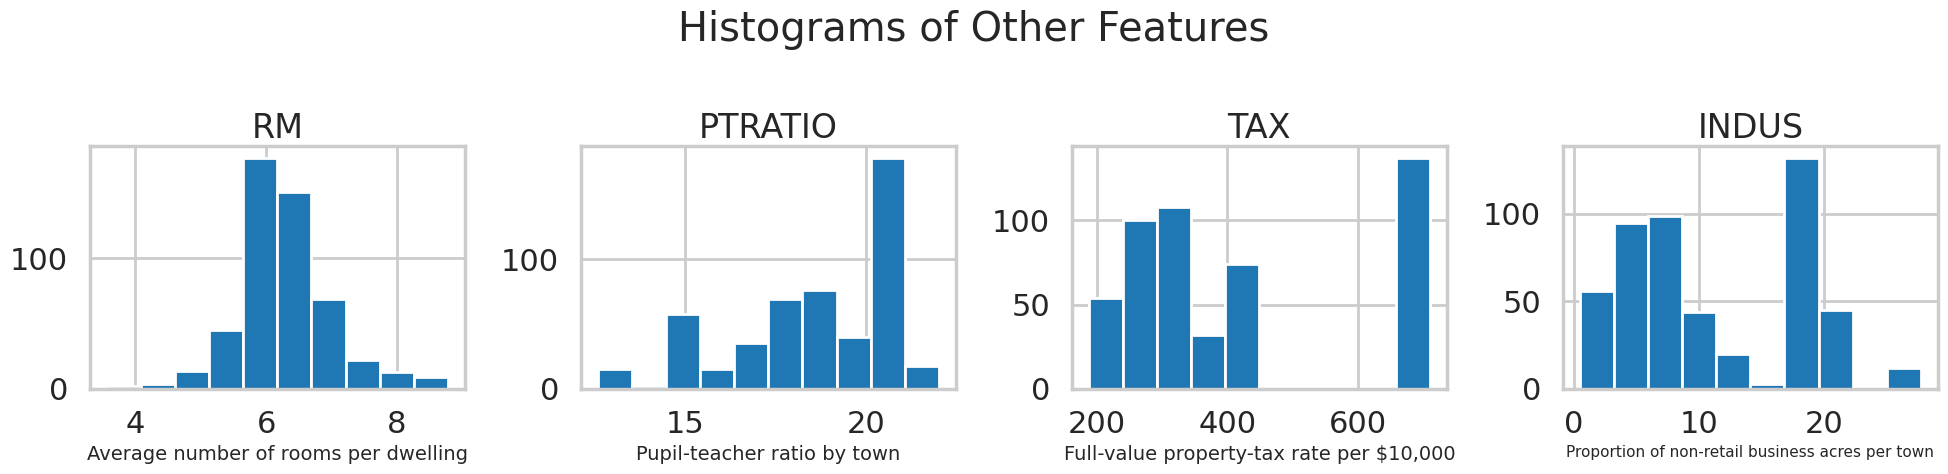

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(bos.RM)
axes[0].set_title("RM")
axes[0].set_xlabel("Average number of rooms per dwelling", fontsize=14)

axes[1].hist(bos.PTRATIO)
axes[1].set_title("PTRATIO")
axes[1].set_xlabel("Pupil-teacher ratio by town", fontsize=14)

axes[2].hist(bos.TAX)
axes[2].set_title("TAX")
axes[2].set_xlabel("Full-value property-tax rate per $10,000", fontsize=14)

axes[3].hist(bos.INDUS)
axes[3].set_title("INDUS")
axes[3].set_xlabel("Proportion of non-retail business acres per town", fontsize=11)

fig.suptitle("Histograms of Other Features")
fig.tight_layout()
plt.show()

- **RM**, *Average number of rooms per dwelling*: Appears to be normally distributed. This is likely a solid predictor for `PRICE` given the positive correlation we observed in the scatterplot.

- **PTRATIO**, *Pupil-teacher ratio by town*: Noticably left skewed with a bit of a spike at the end of the tail. The spike is too slight to call this feature bimodal, but the spread of data leaves me inclined to say this would be a less than ideal predictor, at least on its own.

- **TAX**, *Full-value property-tax rate per $10,000*: A particularly odd distribution that I was curious to see after seeing the surprising scatterplot. The histogram pretty firmly distinguishes two seperate groups, and so I would say its fair to describe this feature as bimodal. While the scatterplot does not show a smooth linear trend, it does show that the more populous subgroup of higher `TAX` values actually seems to have a correlation with lower `PRICE` values, with the lower `TAX` rates being much more spread out between mid to high `PRICE` ranges.

- **INDUS**, *Proportion of non-retail business acres per town*: Also displays a bit of clustering similar to `TAX`. This distribution appears a lot more evidently bimodal, and slightly more spread out when compared to `TAX`. This distribution seems indicative of there being two "types" of towns, with one type being a more concentrated industrialized town (i.e. more "urbanized") and the other being less so (i.e. more "suburban"). The scatterplot, while again not showing a super clear linear relationship, shows a more noticable negative correlation than other features such as `TAX`. It seems that the very generally speaking, the less industrialized an area, the more expensive.

## Part 3: Linear Regression with Boston Housing Data Example
***

Here, 

$Y$ = boston housing prices (called "target" data in python, and referred to as the dependent variable or response variable)

and

$X$ = all the other features (or independent variables, predictors or explanatory variables)

which we will use to fit a linear regression model and predict Boston housing prices. We will use the least-squares method to estimate the coefficients.  

We'll use two ways of fitting a linear regression. We recommend the first but the second is also powerful in its features.

### Fitting Linear Regression using `statsmodels`
***
[Statsmodels](http://statsmodels.sourceforge.net/) is a great Python library for a lot of basic and inferential statistics. It also provides basic regression functions using an R-like syntax, so it's commonly used by statisticians. While we don't cover statsmodels officially in the Data Science Intensive workshop, it's a good library to have in your toolbox. Here's a quick example of what you could do with it. The version of least-squares we will use in statsmodels is called *ordinary least-squares (OLS)*. There are many other versions of least-squares such as [partial least squares (PLS)](https://en.wikipedia.org/wiki/Partial_least_squares_regression) and [weighted least squares (WLS)](https://en.wikipedia.org/wiki/Iteratively_reweighted_least_squares).

In [13]:
# Import regression modules
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [14]:
# statsmodels works nicely with pandas dataframes
# The thing inside the "quotes" is called a formula, a bit on that below
m = ols('PRICE ~ RM',bos).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.49e-74
Time:                        17:10:52   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -34.6706      2.650    -13.084      0.0

#### Interpreting coefficients

There is a ton of information in this output. But we'll concentrate on the coefficient table (middle table). We can interpret the `RM` coefficient (9.1021) by first noticing that the p-value (under `P>|t|`) is so small, basically zero. This means that the number of rooms, `RM`, is a statisticall significant predictor of `PRICE`. The regression coefficient for `RM` of 9.1021 means that *on average, each additional room is associated with an increase of $\$9,100$ in house price net of the other variables*. The confidence interval gives us a range of plausible values for this average change, about ($\$8,279, \$9,925$), definitely not chump change. 

In general, the $\hat{\beta_i}, i > 0$ can be interpreted as the following: "A one unit increase in $x_i$ is associated with, on average, a $\hat{\beta_i}$ increase/decrease in $y$ net of all other variables."

On the other hand, the interpretation for the intercept, $\hat{\beta}_0$ is the average of $y$ given that all of the independent variables $x_i$ are 0.

####  `statsmodels` formulas
***
This formula notation will seem familiar to `R` users, but will take some getting used to for people coming from other languages or are new to statistics.

The formula gives instruction for a general structure for a regression call. For `statsmodels` (`ols` or `logit`) calls you need to have a Pandas dataframe with column names that you will add to your formula. In the below example you need a pandas data frame that includes the columns named (`Outcome`, `X1`,`X2`, ...), but you don't need to build a new dataframe for every regression. Use the same dataframe with all these things in it. The structure is very simple:

`Outcome ~ X1`

But of course we want to to be able to handle more complex models, for example multiple regression is doone like this:

`Outcome ~ X1 + X2 + X3`

In general, a formula for an OLS multiple linear regression is

`Y ~ X1 + X2 + ... + Xp`

This is the very basic structure but it should be enough to get you through the homework. Things can get much more complex. You can force statsmodels to treat variables as categorical with the `C()` function, call numpy functions to transform data such as `np.log` for extremely-skewed data, or fit a model without an intercept by including `- 1` in the formula. For a quick run-down of further uses see the `statsmodels` [help page](http://statsmodels.sourceforge.net/devel/example_formulas.html).


Let's see how our model actually fit our data. We can see below that there is a ceiling effect, we should probably look into that. Also, for large values of $Y$ we get underpredictions, most predictions are below the 45-degree gridlines. 

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> Create a scatterplot between the predicted prices, available in `m.fittedvalues` (where `m` is the fitted model) and the original prices. How does the plot look? Do you notice anything interesting or weird in the plot? Comment on what you see.</p>
</div>

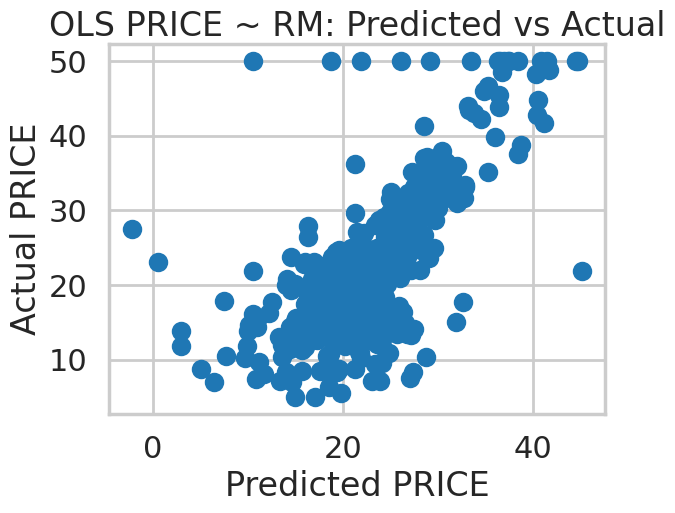

In [15]:
# your turn
plt.scatter(m.fittedvalues, bos.PRICE)
plt.xlabel("Predicted PRICE")
plt.ylabel("Actual PRICE")
plt.title("OLS PRICE ~ RM: Predicted vs Actual")
plt.show()

The plot has a noticably positive correlation, suggesting that there is some decent predictability that's being captured by this model. However, the overall wide spread of points and significant amount of outliers would also imply that there's room for improvement.

### Fitting Linear Regression using `sklearn`


In [16]:
from sklearn.linear_model import LinearRegression
X = bos.drop('PRICE', axis = 1)

# This creates a LinearRegression object
lm = LinearRegression()
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### What can you do with a LinearRegression object? 
***
Check out the scikit-learn [docs here](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). We have listed the main functions here. Most machine learning models in scikit-learn follow this same API of fitting a model with `fit`, making predictions with `predict` and the appropriate scoring function `score` for each model.

Main functions | Description
--- | --- 
`lm.fit()` | Fit a linear model
`lm.predit()` | Predict Y using the linear model with estimated coefficients
`lm.score()` | Returns the coefficient of determination (R^2). *A measure of how well observed outcomes are replicated by the model, as the proportion of total variation of outcomes explained by the model*

#### What output can you get?

In [17]:
# Look inside lm object
# I'm not entirely sure if this is what you're looking for, but let's look at object attributes and methods
dir(lm)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_decision_function',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_class_level_metadata_request_values',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_set_intercept',
 '_validate_params',
 'copy_X',
 'fit',
 'fit_intercept',
 'get_metadata_routing',
 'get_params',
 'n_jobs',
 'positive',
 'predict',
 'score',

Output | Description
--- | --- 
`lm.coef_` | Estimated coefficients
`lm.intercept_` | Estimated intercept 

### Fit a linear model
***

The `lm.fit()` function estimates the coefficients the linear regression using least squares. 

In [18]:
# Use all 13 predictors to fit linear regression model
lm.fit(X, bos.PRICE)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> How would you change the model to not fit an intercept term? Would you recommend not having an intercept? Why or why not? For more information on why to include or exclude an intercept, look [here](https://stats.idre.ucla.edu/other/mult-pkg/faq/general/faq-what-is-regression-through-the-origin/).</p>

<p><b>Exercise:</b> One of the assumptions of the linear model is that the residuals must be i.i.d. (independently and identically distributed). To satisfy this, is it enough that the residuals are normally distributed? Explain your answer.</p>

<p><b>Exercise:</b> True or false. To use linear regression, $Y$ must be normally distributed. Explain your answer.</p>
</div>


In [19]:
# your turn
lm_without_intercept = LinearRegression(fit_intercept=False)
lm_without_intercept.fit(X, bos.PRICE)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


1. Honestly, it's a bit hard for me to make an absolute recommendation before directly looking at the output of both models. But purely based on intuition, I would say we don't really have any particular reason to remove the intercept, and doing so for no reason could very easily cause a worse fit for our regression line. The only reason to remove the intercept is if we could somehow know that our target features and predictive features should definitively share a zero, i.e. intercept through the origin together. That's certainly not the case here as many predictive features at zero would not result in home prices being zero as well.

2. The data being normally distributed does not necessarily mean that the residuals are also independent and equally variant. This kind of information can only really be gathered by understanding the data collection process, which is not in any way communicated via the distribution.

3. False. Linear regression doesn't assume any sort of normality from the target feature $Y$, it only assumes that residuals are normally distributed.

### Estimated intercept and coefficients

Let's look at the estimated coefficients from the linear model using `1m.intercept_` and `lm.coef_`.  

After we have fit our linear regression model using the least squares method, we want to see what are the estimates of our coefficients $\beta_0$, $\beta_1$, ..., $\beta_{13}$: 

$$ \hat{\beta}_0, \hat{\beta}_1, \ldots, \hat{\beta}_{13} $$



In [20]:
print('Estimated intercept coefficient: {}'.format(lm.intercept_))

Estimated intercept coefficient: 36.459488385089955


In [21]:
print('Number of coefficients: {}'.format(len(lm.coef_)))

Number of coefficients: 13


In [22]:
# The coefficients
pd.DataFrame({'features': X.columns, 'estimatedCoefficients': lm.coef_})[['features', 'estimatedCoefficients']]

,features,estimatedCoefficients
0,CRIM,-0.108011
1,ZN,0.046420
2,INDUS,0.020559
3,CHAS,2.686734
4,NOX,-17.766611
5,RM,3.809865
6,AGE,0.000692
7,DIS,-1.475567
8,RAD,0.306049
9,TAX,-0.012335


### Predict Prices 

We can calculate the predicted prices ($\hat{Y}_i$) using `lm.predict`. 

$$ \hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \ldots \hat{\beta}_{13} X_{13} $$

In [23]:
# first five predicted prices
lm.predict(X)[0:5]

array([30.00384338, 25.02556238, 30.56759672, 28.60703649, 27.94352423])

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set III</h3>

<p><b>Exercise:</b> Histogram: Plot a histogram of all the predicted prices. Write a story about what you see. Describe the shape, center and spread of the distribution. Are there any outliers? What might be the reason for them? Should we do anything special with them?</p>

<p><b>Exercise:</b> Scatterplot: Let's plot the true prices compared to the predicted prices to see they disagree (we did this with `statsmodels` before).</p>

<p><b>Exercise:</b> We have looked at fitting a linear model in both `statsmodels` and `scikit-learn`. What are the advantages and disadvantages of each based on your exploration? Based on the information provided by both packages, what advantage does `statsmodels` provide?</p>
</div>

In [24]:
# your turn
price_pred = lm.predict(X)

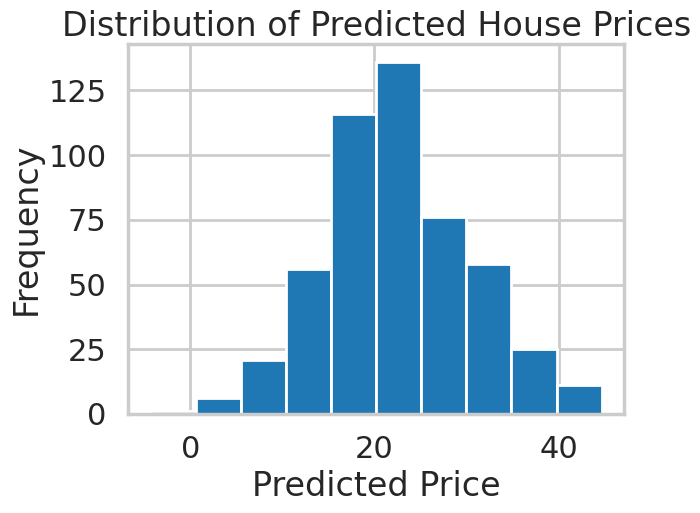

In [25]:
plt.hist(price_pred)
plt.xlabel("Predicted Price")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted House Prices")
plt.show()

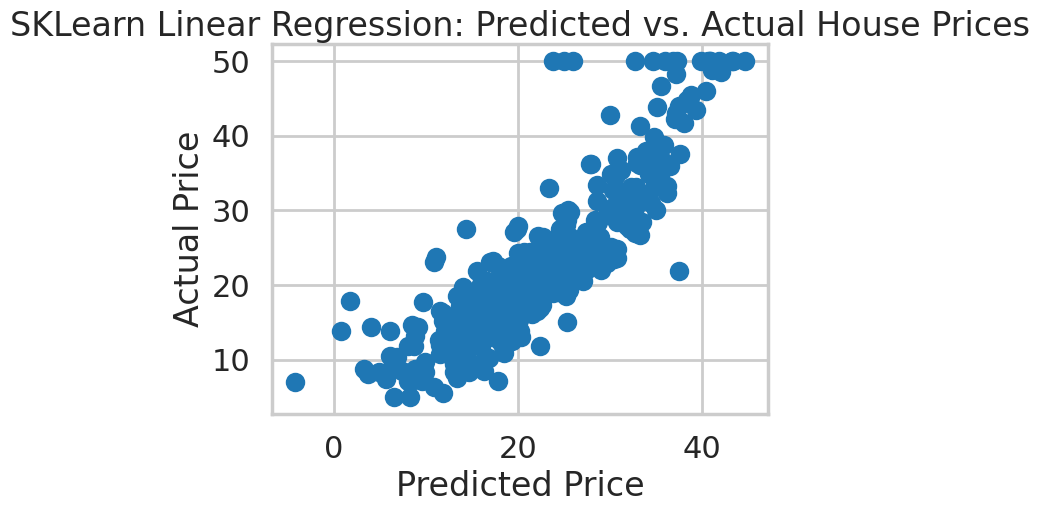

In [26]:
plt.scatter(price_pred, bos.PRICE)
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("SKLearn Linear Regression: Predicted vs. Actual House Prices")
plt.show()

1. The predicted prices are pretty uniformly distributed, almost a picture perfect normal distribution. I don't see any real outliers from this histogram, and I think this would be expected with a linear regression output since it would have steady, linear predictions that trend towards the mean more than real data.

2. This scatterplot seems to be indicative of a much better fit than the statsmodels regression model. The points appear to follow a 45-degree line more closely and are more densely clustered together. Curiously, this plot also shows the same odd behavior at around `PRICE=50` where there's a straight line of predictions that are far more spread out than the rest of the model.

3. It's hard for me to be unbiased in my pros and cons list since the scikit-learn model performed noticably better in this instance, and I'm personally not really familiar with the statsmodels library. However, based on documentation I read online and the output of `m.summary()` eariler, it seems like statsmodels is great for getting statistical information on our data, and thus provides an extra layer beyond just modeling.

### Evaluating the Model: Sum-of-Squares

The partitioning of the sum-of-squares shows the variance in the predictions explained by the model and the variance that is attributed to error.

$$TSS = ESS + RSS$$

#### Residual Sum-of-Squares (aka $RSS$)

The residual sum-of-squares is one of the basic ways of quantifying how much error exists in the fitted model. We will revisit this in a bit.

$$ RSS = \sum_{i=1}^N r_i^2 = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2 $$

In [27]:
print(np.sum((bos.PRICE - lm.predict(X)) ** 2))

11078.784577954977


#### Explained Sum-of-Squares (aka $ESS$)

The explained sum-of-squares measures the variance explained by the regression model.

$$ESS = \sum_{i=1}^N \left( \hat{y}_i - \bar{y} \right)^2 = \sum_{i=1}^N \left( \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) - \bar{y} \right)^2$$

In [28]:
print(np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))

31637.510837064507


### Evaluating the Model: The Coefficient of Determination ($R^2$)

The coefficient of determination, $R^2$, tells us the percentage of the variance in the response variable $Y$ that can be explained by the linear regression model.

$$ R^2 = \frac{ESS}{TSS} $$

The $R^2$ value is one of the most common metrics that people use in describing the quality of a model, but it is important to note that *$R^2$ increases artificially as a side-effect of increasing the number of independent variables.* While $R^2$ is reported in almost all statistical packages, another metric called the *adjusted $R^2$* is also provided as it takes into account the number of variables in the model, and can sometimes even be used for non-linear regression models!

$$R_{adj}^2 = 1 - \left( 1 - R^2 \right) \frac{N - 1}{N - K - 1} = R^2 - \left( 1 - R^2 \right) \frac{K}{N - K - 1} = 1 - \frac{\frac{RSS}{DF_R}}{\frac{TSS}{DF_T}}$$

where $N$ is the number of observations, $K$ is the number of variables, $DF_R = N - K - 1$ is the degrees of freedom associated with the residual error and $DF_T = N - 1$ is the degrees of the freedom of the total error.

### Evaluating the Model: Mean Squared Error and the $F$-Statistic
***
The mean squared errors are just the *averages* of the sum-of-squares errors over their respective degrees of freedom.

$$MSE = \frac{RSS}{N-K-1}$$

$$MSR = \frac{ESS}{K}$$

**Remember:** Notation may vary across resources particularly the use of $R$ and $E$ in $RSS/ESS$ and $MSR/MSE$. In some resources, E = explained and R = residual. In other resources, E = error and R = regression (explained). **This is a very important distinction that requires looking at the formula to determine which naming scheme is being used.**

Given the MSR and MSE, we can now determine whether or not the entire model we just fit is even statistically significant. We use an $F$-test for this. The null hypothesis is that all of the $\beta$ coefficients are zero, that is, none of them have any effect on $Y$. The alternative is that *at least one* $\beta$ coefficient is nonzero, but it doesn't tell us which one in a multiple regression:

$$H_0: \beta_i = 0, \mbox{for all $i$} \\
H_A: \beta_i > 0, \mbox{for some $i$}$$ 

$$F = \frac{MSR}{MSE} = \left( \frac{R^2}{1 - R^2} \right) \left( \frac{N - K - 1}{K} \right)$$
 
Once we compute the $F$-statistic, we can use the $F$-distribution with $N-K$ and $K-1$ degrees of degrees of freedom to get a p-value.

**Warning!** The $F$-statistic mentioned in this section is NOT the same as the F1-measure or F1-value discused in Unit 7.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set IV</h3>

<p>Let's look at the relationship between `PTRATIO` and housing price.</p>

<p><b>Exercise:</b> Try fitting a linear regression model using only the 'PTRATIO' (pupil-teacher ratio by town) and interpret the intercept and the coefficients.</p>

<p><b>Exercise:</b> Calculate (or extract) the $R^2$ value. What does it tell you?</p>

<p><b>Exercise:</b> Compute the $F$-statistic. What does it tell you?</p>

<p><b>Exercise:</b> Take a close look at the $F$-statistic and the $t$-statistic for the regression coefficient. What relationship do you notice? Note that this relationship only applies in *simple* linear regression models.</p>
</div>

In [29]:
# your turn
lm_ptratio = ols('PRICE ~ PTRATIO', bos).fit()
print(lm_ptratio.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     175.1
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           1.61e-34
Time:                        17:10:52   Log-Likelihood:                -1764.8
No. Observations:                 506   AIC:                             3534.
Df Residuals:                     504   BIC:                             3542.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     62.3446      3.029     20.581      0.0

Interpreting the intercept $\textbf{62.34}$ here is a bit tricky. The `PTRATIO` is meant to represent the ratio between pupils and teachers per town, so the intercept would be the value of homes in an area where this ratio is zero. Perhaps this is the case for some ultra rural towns in Boston, but it seems unrealistic to me, and something that I would suggest should not be interpreted literally. So a more fair interpretation is that the intercept is simply the ceiling cost of homes projected by our model based on the predictability that `PTRATIO` grants us. 

The coefficient $\textbf{-2.16}$ has a negative slope, which tells us pretty directly that a higher `PTRATIO` tends to be assocuated with lower `PRICE` values.

The R-squared value $\textbf{0.26}$, i.e. the coefficient of determination, is indicative of the proportion of the dependent variable's variance that is explained by the independent variable. In simpler terms, this model suggests that about **26%** of the Boston home price variability can be explained by the pupil-teacher ratio.

The F-statistic $\textbf{175.1}$ is relatively high here, in conjunction with an extremely low p-value, so we can interpret this as an indication that `PTRATIO` is a statistically significant predictor of `PRICE`.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set V</h3>

<p>Fit a linear regression model using three independent variables</p>

<ol>
<li> 'CRIM' (per capita crime rate by town)
<li> 'RM' (average number of rooms per dwelling)
<li> 'PTRATIO' (pupil-teacher ratio by town)
</ol>

<p><b>Exercise:</b> Compute or extract the $F$-statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Compute or extract the $R^2$ statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Which variables in the model are significant in predicting house price? Write a story that interprets the coefficients.</p>
</div>

In [30]:
# your turn
lm_3 = ols('PRICE ~ CRIM + RM + PTRATIO', bos).fit()
print(lm_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     245.2
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           6.15e-98
Time:                        17:10:52   Log-Likelihood:                -1612.0
No. Observations:                 506   AIC:                             3232.
Df Residuals:                     502   BIC:                             3249.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.3707      4.034     -0.836      0.4

The F-statistic $\textbf{245.2}$ is higher this time around, by a sum of about half the previous F-statistic. We know the model is statistically significant, which admittedly was already a given as we included `PTRATIO`, but we also know it is even more significant with in tandum of `CRIM` and `RM`.

My first instinct was to simply subtract the R-squared values and say "`CRIM` and `RM` account for `lm_3.rsquared` - `lm_ptratio.rsquared` = 0.336 of house price variability", but after some careful research online, it seems like it's a bit more complicated than that. Since there is a complex interaction between variables in any given model's predictability, you aren't able to infer any single variable's weight with simple arithmetic like that.

However, we do know from the R-squared value $\textbf{0.594}$ that this model is accounting for a somewhat higher percentage of variability we observe in house pricing, albeit still leaving a decent amount of variability unaccounted for.

Taking a look at the coefficients we can infer a bit about what any single variable's influence is on house pricing, given that the remaining variables are constant. 

First, taking a look at how to interpret each variable individually based on documentation provided by *UCI Machine Learning Repository*:
- `PRICE = 1` is equivalent to the median price of a homes being $1,000.
- `CRIM = 1` is equivalent to 1 unit of per capita crime rate by town. Documentation on the dataset doesn't seem to explicitly state this, but this is typically measured as number of crimes committed per 100,000 people, so another interpretation is 1 crime per 100,000 in any given town.
- `RM = 1` is equivalent to an average of 1 room per dwelling.
- `PTRATIO = 1` is equivalent to a pupil-teacher ratio of 1, i.e. 1 student to 1 teacher.

Using these units of measure, we can interpret each coefficient as they relate to house pricing: 
- A `CRIM` coefficient of $\textbf{-0.2050}$ likely means that our model predicts for every 1 crime comitted per 100,000 people in a given town, median home prices go down by about **$205.00**.
- An `RM` coefficient of $\textbf{7.3804}$ means that our model predicts for every 1 additional room a dwelling has, median home prices increase by about **$7,380.40**.
- A `PTRATIO` coefficient of $\textbf{-1.0695}$ means that our model predicts for every 1 additional student per teacher, median home prices decrease by about **$1,069.50**.

## Part 4: Comparing Models

During modeling, there will be times when we want to compare models to see which one is more predictive or fits the data better. There are many ways to compare models, but we will focus on two.

### The $F$-Statistic Revisited

The $F$-statistic can also be used to compare two *nested* models, that is, two models trained on the same dataset where one of the models contains a *subset* of the variables of the other model. The *full* model contains $K$ variables and the *reduced* model contains a subset of these $K$ variables. This allows us to add additional variables to a base model and then test if adding the variables helped the model fit.

$$F = \frac{\left( \frac{RSS_{reduced} - RSS_{full}}{DF_{reduced} - DF_{full}} \right)}{\left( \frac{RSS_{full}}{DF_{full}} \right)}$$

where $DF_x = N - K_x - 1$ where $K_x$ is the number of variables in model $x$.

### Akaike Information Criterion (AIC)

Another statistic for comparing two models is AIC, which is based on the likelihood function and takes into account the number of variables in the model.

$$AIC = 2 K - 2 \log_e{L}$$

where $L$ is the likelihood of the model. AIC is meaningless in the absolute sense, and is only meaningful when compared to AIC values from other models. Lower values of AIC indicate better fitting models.

`statsmodels` provides the AIC in its output.

<div class="span5 alert alert-info">
<h3>Part 4 Checkup Exercises</h3>

<p><b>Exercise:</b> Find another variable (or two) to add to the model we built in Part 3. Compute the $F$-test comparing the two models as well as the AIC. Which model is better?</p>
</div>

In [31]:
lm_4 = ols('PRICE ~ CRIM + RM + PTRATIO + NOX + INDUS', bos).fit()
print(lm_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     160.2
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          2.18e-101
Time:                        17:10:52   Log-Likelihood:                -1598.3
No. Observations:                 506   AIC:                             3209.
Df Residuals:                     500   BIC:                             3234.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.5484      4.496      1.456      0.1

In [32]:
# Residual sum of squares
rss_reduced = np.sum((bos.PRICE - lm_3.fittedvalues) ** 2)
rss_full = np.sum((bos.PRICE - lm_4.fittedvalues) ** 2)

# Degrees of freedom
dof_reduced = len(bos) - 3 - 1
dof_full = len(bos) - 5 - 1

# F-statistic
f_stat = ((rss_reduced - rss_full) / (dof_reduced - dof_full)) / (rss_full / dof_full)
print("F-statistic: ", f_stat)

F-statistic:  13.874238267472654


In [33]:
# AIC comparison
print("AIC for reduced model: ", lm_3.aic)
print("AIC for full model: ", lm_4.aic)

AIC for reduced model:  3231.945123544996
AIC for full model:  3208.615202543101


Both our F-statstic and AIC results are indicative of the full model $PRICE ~ CRIM + RM + PTRATIO + NOX + INDUS$ is a notably better fit relative to the reduced model.


## Part 5: Evaluating the Model via Model Assumptions and Other Issues
***
Linear regression makes several assumptions. It is always best to check that these assumptions are valid after fitting a linear regression model.

<div class="span5 alert alert-danger">
<ul>
  <li>**Linearity**. The dependent variable $Y$ is a linear combination of the regression coefficients and the independent variables $X$. This can be verified with a scatterplot of each $X$ vs. $Y$ and plotting correlations among $X$. Nonlinearity can sometimes be resolved by [transforming](https://onlinecourses.science.psu.edu/stat501/node/318) one or more independent variables, the dependent variable, or both. In other cases, a [generalized linear model](https://en.wikipedia.org/wiki/Generalized_linear_model) or a [nonlinear model](https://en.wikipedia.org/wiki/Nonlinear_regression) may be warranted.</li>
  <li>**Constant standard deviation**. The SD of the dependent variable $Y$ should be constant for different values of X. We can check this by plotting each $X$ against $Y$ and verifying that there is no "funnel" shape showing data points fanning out as $X$ increases or decreases. Some techniques for dealing with non-constant variance include weighted least squares (WLS), [robust standard errors](https://en.wikipedia.org/wiki/Heteroscedasticity-consistent_standard_errors), or variance stabilizing transformations.
    </li>
  <li> **Normal distribution for errors**.  The $\epsilon$ term we discussed at the beginning are assumed to be normally distributed. This can be verified with a fitted values vs. residuals plot and verifying that there is no pattern, and with a quantile plot.
  $$ \epsilon_i \sim N(0, \sigma^2)$$
Sometimes the distributions of responses $Y$ may not be normally distributed at any given value of $X$.  e.g. skewed positively or negatively. </li>
<li> **Independent errors**.  The observations are assumed to be obtained independently.
    <ul>
        <li>e.g. Observations across time may be correlated
    </ul>
</li>
</ul>  

</div>

There are some other issues that are important investigate with linear regression models.

<div class="span5 alert alert-danger">
<ul>
  <li>**Correlated Predictors:** Care should be taken to make sure that the independent variables in a regression model are not too highly correlated. Correlated predictors typically do not majorly affect prediction, but do inflate standard errors of coefficients making interpretation unreliable. Common solutions are dropping the least important variables involved in the correlations, using regularlization, or, when many predictors are highly correlated, considering a dimension reduction technique such as principal component analysis (PCA).
  <li>**Influential Points:** Data points that have undue influence on the regression model. These points can be high leverage points or outliers. Such points are typically removed and the regression model rerun.
</ul>
</div>


<div class="span5 alert alert-info">
<h3>Part 5 Checkup Exercises</h3>

<p>Take the reduced model from Part 3 to answer the following exercises. Take a look at [this blog post](http://mpastell.com/2013/04/19/python_regression/) for more information on using statsmodels to construct these plots.</p>
    
<p><b>Exercise:</b> Construct a fitted values versus residuals plot. What does the plot tell you? Are there any violations of the model assumptions?</p>

<p><b>Exercise:</b> Construct a quantile plot of the residuals. What does the plot tell you?</p>

<p><b>Exercise:</b> What are some advantages and disadvantages of the fitted vs. residual and quantile plot compared to each other?</p>

<p><b>Exercise:</b> Identify any outliers (if any) in your model and write a story describing what these outliers might represent.</p>

<p><b>Exercise:</b> Construct a leverage plot and identify high leverage points in the model. Write a story explaining possible reasons for the high leverage points.</p>

<p><b>Exercise:</b> Remove the outliers and high leverage points from your model and run the regression again. How do the results change?</p>
</div>

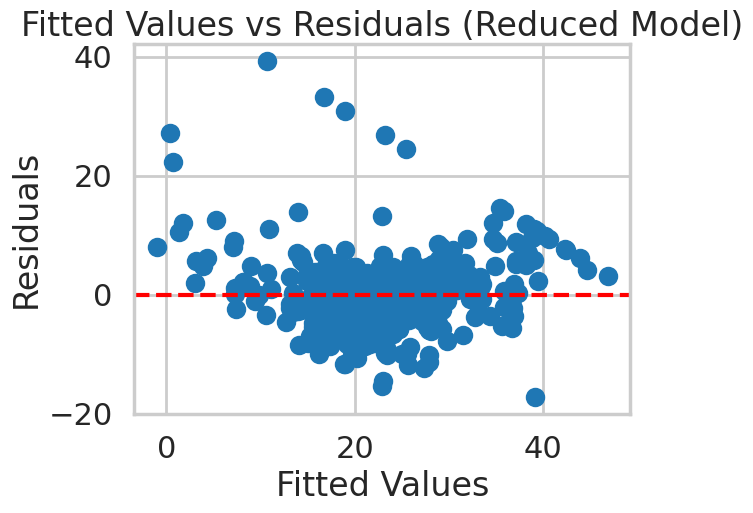

In [34]:
# Your turn.
fitted_values = lm_3.fittedvalues
residuals = lm_3.resid

plt.scatter(fitted_values, residuals)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted Values vs Residuals (Reduced Model)")
plt.show()

The fitted vs. residuals plot has taken a fairly odd shape. There is a noticable U-shape to the scattered points, which is said to be (according to the internet) indicative of our linear model being unable to fully model the relationshnip between our predictive features and our target feature, i.e. it's unlikely that our data has a linear relationship. Moreover, there is yet again a strange straight line at the maximum values of the plot, this time at a 135 degree-ish angle. I'm not entirely sure what to make of this line, but given that we've seen this in the previous scatterplots of our models, I believe it must mean that there's some underlying issue with our data that's causing our model to mispredict values at the maximum home price.

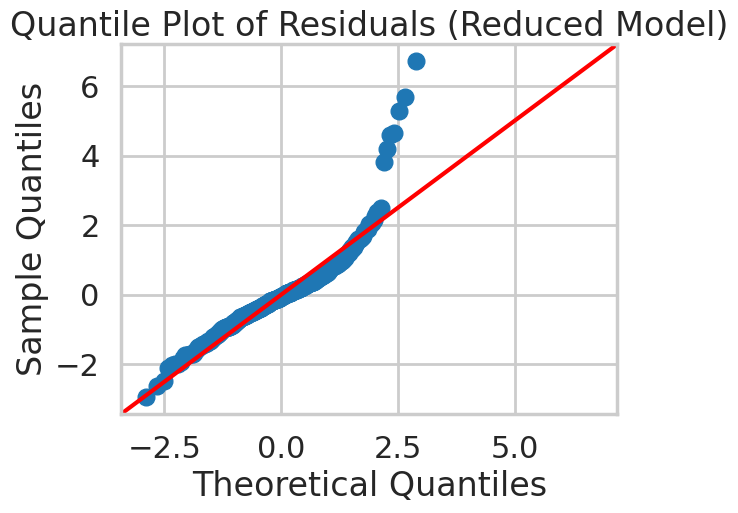

In [35]:
sm.qqplot(lm_3.resid, line='45', fit=True)
plt.title("Quantile Plot of Residuals (Reduced Model)")
plt.show()

The quantile plot lets us know how normal our residuals are. Since the low to middle quantiles are relatively aligned at the 45 degree line, we can say that our small and middle-sized residuals are likely normally distributed. However, the liftoff we see at the larger quantiles would imply that our largest residuals are abnormally large. This aligns with our previous findings of our model's accuracy being much lower at the largest `PRICE` values. 

The fitted vs. residuals plot helps us evaluate the linearity and homoscedasticity of our model by showing how residuals behave across the range of fitted values.The quantile plot helps us evaluate the normality of our residuals. They are both great at evaluating the overall "health" and fit of the model, but serve somewhat different purposes.

In [36]:
influence = lm_3.get_influence()
influence_summary = influence.summary_frame()
influence_summary.head()

,dfb_Intercept,dfb_CRIM,dfb_RM,dfb_PTRATIO,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,-0.035140,0.000412,0.004115,0.049678,0.001045,-0.817854,0.006208,-0.064642,-0.817584,-0.064621
1,-0.003705,0.008572,-0.001235,0.004238,0.000199,-0.575202,0.002397,-0.028193,-0.574819,-0.028174
2,-0.025394,-0.005671,0.037987,0.006262,0.000653,0.697322,0.005347,0.051126,0.696965,0.051100
3,-0.036905,-0.012698,0.042049,0.022197,0.000911,0.875186,0.004736,0.060373,0.874982,0.060359
4,-0.059036,-0.015171,0.068097,0.033309,0.001991,1.167191,0.005811,0.089234,1.167614,0.089266


In [37]:
outliers_influence = influence_summary[np.abs(influence_summary['standard_resid']) >  3]
outliers_influence

,dfb_Intercept,dfb_CRIM,dfb_RM,dfb_PTRATIO,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
365,0.605635,-0.137634,-0.844851,-0.097319,0.189738,4.696069,0.033270,0.871177,4.797961,0.890080
367,0.430608,0.092503,-0.578760,-0.098429,0.100813,3.853096,0.026444,0.635022,3.907470,0.643984
368,0.320097,-0.097792,-0.541507,0.068764,0.104185,6.719690,0.009145,0.645553,7.036931,0.676030
369,-0.236366,0.026106,0.191963,0.212262,0.026002,4.575289,0.004944,0.322503,4.669117,0.329117
370,-0.295195,0.056773,0.275470,0.219756,0.032887,4.191566,0.007432,0.362694,4.262646,0.368845
371,-0.129231,0.113511,0.063247,0.167953,0.026477,5.284871,0.003778,0.325436,5.432903,0.334552
372,-0.028292,0.073844,-0.072677,0.145695,0.029296,5.679861,0.003619,0.342321,5.865813,0.353528


In [38]:
outliers = bos.iloc[outliers_influence.index]
outliers['PREDICTED_PRICE'] = lm_3.fittedvalues[outliers_influence.index]
outliers

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PREDICTED_PRICE
365,4.55587,0.0,18.1,0.0,0.718,3.561,87.9,1.6132,24.0,666.0,20.2,354.70,7.12,27.5,0.372333
367,13.52220,0.0,18.1,0.0,0.631,3.863,100.0,1.5106,24.0,666.0,20.2,131.42,13.33,23.1,0.763471
368,4.89822,0.0,18.1,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0,10.701164
369,5.66998,0.0,18.1,1.0,0.631,6.683,96.8,1.3567,24.0,666.0,20.2,375.33,3.73,50.0,23.185628
370,6.53876,0.0,18.1,1.0,0.631,7.016,97.5,1.2024,24.0,666.0,20.2,392.05,2.96,50.0,25.465239
371,9.23230,0.0,18.1,0.0,0.631,6.216,100.0,1.1691,24.0,666.0,20.2,366.15,9.53,50.0,19.008840
372,8.26725,0.0,18.1,1.0,0.668,5.875,89.6,1.1296,24.0,666.0,20.2,347.88,8.88,50.0,16.689917


Hohoho, so just as I have been predicting, nearly all of the outliers are at the maximum price point of `50.0`. Moreover, it seems quite strange that they're all exactly 50. Perhaps the dataset itself was modified to cap prices at 50. We'll take a look at some Z-scores to judge for ourselves if this is an abnormal price cap, or just some sort of weird coincidence.

In [39]:
# CRIM Z-scores
outliers['CRIM_Z'] = (outliers['CRIM'] - bos.CRIM.mean()) / bos.CRIM.std()
outliers[['CRIM', 'CRIM_Z']]


,CRIM,CRIM_Z
365,4.55587,0.109555
367,13.52220,1.151965
368,4.89822,0.149356
369,5.66998,0.239080
370,6.53876,0.340083
371,9.23230,0.653229
372,8.26725,0.541034


In [48]:
# RM Z-scores
outliers['RM_Z'] = (outliers['RM'] - bos.RM.mean()) / bos.RM.std()
outliers[['RM', 'RM_Z']]

,RM,RM_Z
365,3.561,-3.876413
367,3.863,-3.446592
368,4.970,-1.871054
369,6.683,0.566974
370,7.016,1.040916
371,6.216,-0.097684
372,5.875,-0.583012


In [41]:
# PTRATIO Z-scores
outliers['PTRATIO_Z'] = (outliers['PTRATIO'] - bos.PTRATIO.mean()) / bos.PTRATIO.std()
outliers[['PTRATIO', 'PTRATIO_Z']]

,PTRATIO,PTRATIO_Z
365,20.2,0.805778
367,20.2,0.805778
368,20.2,0.805778
369,20.2,0.805778
370,20.2,0.805778
371,20.2,0.805778
372,20.2,0.805778


So the two points `365` and `367` are the only ones to show extrordinarily unusual z-scores, specifically in number of rooms. These two points also happen to be the only outliers that do not have a price of 50. It is possible that these two entries have the wrong number of rooms, or that they're vastly overpriced Bostonian dwellings. The repeating price of 50 amongst the remaining outliers leads me to believe that there could be some kind of data entry error that is likely the cause for the large residuals in the prediction of these outliers.

<Figure size 1000x600 with 0 Axes>

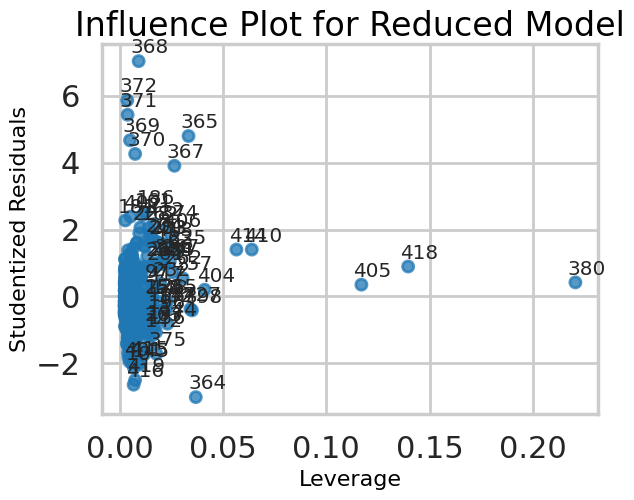

In [47]:
plt.figure(figsize=(10, 6))
sm.graphics.influence_plot(lm_3, criterion="cooks", size=8)
plt.title("Influence Plot for Reduced Model")
plt.rcParams['font.size'] = 10
plt.show()

In [58]:
high_leverage_influence = influence_summary[influence_summary['hat_diag'] > 0.05]
high_leverage_influence

,dfb_Intercept,dfb_CRIM,dfb_RM,dfb_PTRATIO,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
380,-0.024896,0.220433,0.056969,-0.025819,0.012558,0.421333,0.220554,0.224125,0.420988,0.223941
405,0.006071,0.126452,0.006301,-0.020662,0.004146,0.353878,0.116949,0.128783,0.353569,0.128671
410,0.013227,0.355592,0.014385,-0.046489,0.033519,1.401601,0.063889,0.366161,1.402952,0.366514
414,0.111967,0.295909,-0.113389,-0.074649,0.029396,1.401732,0.056465,0.342908,1.403084,0.343238
418,0.001694,0.356404,0.038088,-0.054241,0.032546,0.895820,0.139582,0.360811,0.895644,0.360740


In [59]:
high_leverage_points = bos.iloc[high_leverage_influence.index]
high_leverage_points['PREDICTED_PRICE'] = lm_3.fittedvalues[high_leverage_influence.index]
high_leverage_points

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PREDICTED_PRICE
380,88.9762,0.0,18.1,0.0,0.671,6.968,91.9,1.4165,24.0,666.0,20.2,396.90,17.21,10.4,8.214533
405,67.9208,0.0,18.1,0.0,0.693,5.683,100.0,1.4254,24.0,666.0,20.2,384.97,22.98,5.0,3.046237
410,51.1358,0.0,18.1,0.0,0.597,5.757,100.0,1.4130,24.0,666.0,20.2,2.60,10.11,15.0,7.032655
414,45.7461,0.0,18.1,0.0,0.693,4.519,100.0,1.6582,24.0,666.0,20.2,88.27,36.98,7.0,-0.999617
418,73.5341,0.0,18.1,0.0,0.679,5.957,100.0,1.8026,24.0,666.0,20.2,16.45,20.62,8.8,3.917963


In [60]:
# I can already tell at a glance that the crime rate on these points is crazy high
high_leverage_points['CRIM_Z'] = (high_leverage_points['CRIM'] - bos.CRIM.mean()) / bos.CRIM.std()
high_leverage_points[['CRIM', 'CRIM_Z']]


,CRIM,CRIM_Z
380,88.9762,9.924110
405,67.9208,7.476247
410,51.1358,5.524853
414,45.7461,4.898257
418,73.5341,8.128839


In [ ]:
# Let's take a quick look at number of rooms too
high_leverage_points['RM_Z'] = (high_leverage_points['RM'] - bos.RM.mean()) / bos.RM.std()
high_leverage_points[['RM', 'RM_Z']]

,RM,RM_Z
380,6.968,0.972600
405,5.683,-0.856276
410,5.757,-0.750956
414,4.519,-2.512940
418,5.957,-0.466306


All of the high leverage points have a `CRIM` Z-score above 3, placing them all well above the 99th percentile of crime rate. Since these points are such strong outliers in terms of crime rate, they could be influencing the regression model significantly in this regard.

In [62]:
outliers_and_leverage = pd.concat([outliers, high_leverage_points], ignore_index=False)
bos_without_outliers_leverage = bos.drop(outliers_and_leverage.index)

lm_5 = ols('PRICE ~ CRIM + RM + PTRATIO', bos_without_outliers_leverage).fit()
lm_5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     426.4
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          3.64e-136
Time:                        17:49:57   Log-Likelihood:                -1456.3
No. Observations:                 494   AIC:                             2921.
Df Residuals:                     490   BIC:                             2937.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.8011      3.259     -2.087      0.037     -13.205      -0.397
CRIM          -0.3236      0.039     -8.337      0.000      -0.400      -0.247
RM             7.9271      0.332     23.855      0.000       7.274       8.580
PTRATIO       -1.0767      0.107    -10.098      0.000      -1.286      -0.867
==============================================================================
Omnibus:                       22.730   Durbin-Watson:                   1.147
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.365
Skew:                           0.259   Prob(JB):                     1.41e-10
Kurtosis:                       4.392   Cond. No.                         312.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [63]:
print("Original R-squared: ", lm_3.rsquared)
print("R-squared without outliers and leverage points: ", lm_5.rsquared)

print("Original AIC: ", lm_3.aic)
print("AIC without outliers and leverage points: ", lm_5.aic)

Original R-squared:  0.5943412940723474
R-squared without outliers and leverage points:  0.7230620634597211
Original AIC:  3231.945123544996
AIC without outliers and leverage points:  2920.53861348654


Removing the outliers and high leverage points improved the R-squared and AIC significantly, indicating a much better model fit. It's important to note that these results alone do not prove our model is sufficient for predicting this dataset. We used R-squared and AIC to determine the in-sample data fit of the model, but still know very little about how the model would perform on a test set. That being said, this is a clear lesson on how strongly influential outliers can be for linear regression.